# NSL-KDD: schema and data audit

Step 1 prepares an evidence-based feature catalogue for GMM and TabDDPM. Run with the project's `.venv` kernel (Polars is managed by `uv`). This notebook inspects the released CSV without transforming or dropping rows. Full-data statistics are exploratory; later preprocessing must be fitted only on development normal rows.

In [87]:
from pathlib import Path

import matplotlib.pyplot as plt
import polars as pl
from IPython.display import display

cwd = Path.cwd().resolve()
train_path = next(
    (
        root / "data" / "NSL-KDD" / "train.csv"
        for root in (cwd, *cwd.parents)
        if (root / "data" / "NSL-KDD" / "train.csv").is_file()
    ),
    None,
)
if train_path is None:
    raise FileNotFoundError("Could not find data/NSL-KDD/train.csv from this working directory.")

train_df = pl.read_csv(train_path, has_header=True)
LABEL = "is_anomaly"  # Same for both NSL-KDD and UNSW-NB15 datasets
CATEGORICAL = ["protocol_type", "service", "flag"]
BINARY = ["land", "logged_in", "root_shell", "is_host_login", "is_guest_login"]
DISCRETE = {"su_attempted": [0, 1, 2]}
COUNTS = [
    "duration",
    "src_bytes",
    "dst_bytes",
    "wrong_fragment",
    "urgent",
    "hot",
    "num_failed_logins",
    "num_compromised",
    "num_root",
    "num_file_creations",
    "num_shells",
    "num_access_files",
    "num_outbound_cmds",
    "count",
    "srv_count",
    "dst_host_count",
    "dst_host_srv_count",
]
RATES = [
    "serror_rate",
    "srv_serror_rate",
    "rerror_rate",
    "srv_rerror_rate",
    "same_srv_rate",
    "diff_srv_rate",
    "srv_diff_host_rate",
    "dst_host_same_srv_rate",
    "dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate",
    "dst_host_srv_serror_rate",
    "dst_host_rerror_rate",
    "dst_host_srv_rerror_rate",
]
EXPECTED_FEATURES = CATEGORICAL + BINARY + list(DISCRETE) + COUNTS + RATES
features = [c for c in train_df.columns if c != LABEL]
assert len(EXPECTED_FEATURES) == len(set(EXPECTED_FEATURES)) == 41
assert set(train_df.columns) == set([*EXPECTED_FEATURES, LABEL]), "Unexpected CSV schema"
assert train_df.height > 0, "Training data is empty"
assert train_df[LABEL].null_count() == 0, "Missing labels"
assert set(train_df[LABEL].unique().to_list()) == {0, 1}, "Expected both binary labels 0 and 1"
assert all(train_df.schema[c] == pl.String for c in CATEGORICAL), "Categoricals must be strings"
numerical = [c for c in features if c not in CATEGORICAL]
assert all(train_df.schema[c].is_numeric() for c in numerical), (
    "Numerical feature has unexpected dtype"
)

normal_df = train_df.filter(pl.col(LABEL) == 0)
attack_df = train_df.filter(pl.col(LABEL) == 1)
print(f"Source: {train_path}")
print(f"Rows: {train_df.height:,}; features: {len(features)}")
display(train_df.head())
display(
    train_df.group_by(LABEL)
    .len()
    .sort(LABEL)
    .with_columns((pl.col("len") / train_df.height).alias("fraction"))
)

Source: C:\Users\tanyi\OneDrive\Home Desktop\Documents\GitHub\cs5344-data-augmentation-for-anomaly-detection\data\NSL-KDD\train.csv
Rows: 30,000; features: 41


duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,protocol_type,service,flag,is_anomaly
i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,str,i64
0,810,332,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,3,1,0.0,0.0,0.0,0.0,0.33,0.67,0.0,85,157,0.58,0.06,0.01,0.01,0.0,0.0,0.0,0.0,"""tcp""","""smtp""","""SF""",0
0,516,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,271,271,0.0,0.0,0.0,0.0,1.0,0.0,0.0,255,255,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,"""udp""","""other""","""SF""",0
0,217,784,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,14,15,0.0,0.0,0.0,0.0,1.0,0.0,0.13,255,255,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""tcp""","""http""","""SF""",0
0,223,187,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,7,9,0.0,0.0,0.0,0.0,1.0,0.0,0.33,7,255,1.0,0.0,0.14,0.06,0.0,0.0,0.0,0.0,"""tcp""","""http""","""SF""",0
0,211,1628,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,2,2,0.0,0.0,0.0,0.0,1.0,0.0,0.0,2,2,1.0,0.0,0.5,0.0,0.0,0.0,0.0,0.0,"""tcp""","""http""","""SF""",0


is_anomaly,len,fraction
i64,u32,f64
0,20000,0.666667
1,10000,0.333333


## Feature catalogue

Semantic types are explicit for NSL-KDD; integer storage alone does not distinguish a count from a binary indicator or categorical state. `duration` is recorded in integer seconds. `su_attempted` retains states 0, 1, and 2. Constancy is recorded separately from semantic type, so an all-zero binary column remains binary in the catalogue.

In [88]:
def semantic_type(column):
    if column in CATEGORICAL:
        return "categorical"
    if column in BINARY:
        return "binary"
    if column in DISCRETE:
        return "discrete_state"
    if column in RATES:
        return "bounded_rate"
    if column in COUNTS:
        return "count"
    return "continuous"


feature_catalogue = pl.DataFrame(
    [
        {
            "position": i,
            "feature": c,
            "dtype": str(train_df.schema[c]),
            "semantic_type": semantic_type(c),
            "n_unique_all": train_df[c].n_unique(),
            "n_unique_normal": normal_df[c].n_unique(),
            "constant_normal": normal_df[c].n_unique() == 1,
            "normal_constant_value": str(normal_df[c][0]) if normal_df[c].n_unique() == 1 else None,
        }
        for i, c in enumerate(features)
    ]
)
with pl.Config(tbl_rows=50):
    display(feature_catalogue)

position,feature,dtype,semantic_type,n_unique_all,n_unique_normal,constant_normal,normal_constant_value
i64,str,str,str,i64,i64,bool,str
0,"""duration""","""Int64""","""count""",875,686,false,null
1,"""src_bytes""","""Int64""","""count""",1992,1973,false,null
2,"""dst_bytes""","""Int64""","""count""",4990,4971,false,null
3,"""land""","""Int64""","""binary""",2,2,false,null
4,"""wrong_fragment""","""Int64""","""count""",3,1,true,"""0"""
5,"""urgent""","""Int64""","""count""",2,2,false,null
6,"""hot""","""Int64""","""count""",19,19,false,null
7,"""num_failed_logins""","""Int64""","""count""",5,5,false,null
8,"""logged_in""","""Int64""","""binary""",2,2,false,null


## Data quality and domain checks

Inspect nulls, blank category tokens, nonfinite numbers, nonnegative integer counts, binary/state domains, and rate bounds. Domain violations stop the notebook before distribution analysis. Empirical maxima are observations, not physical limits.

In [89]:
quality_rows = []
for c in train_df.columns:
    s = train_df[c]
    nonfinite = int((~s.is_finite()).fill_null(False).sum()) if s.dtype.is_numeric() else 0
    blank = int((s.str.strip_chars() == "").fill_null(False).sum()) if s.dtype == pl.String else 0
    violations = 0
    if c in BINARY:
        violations = int((~s.is_in([0, 1])).fill_null(False).sum())
    elif c in DISCRETE:
        violations = int((~s.is_in(DISCRETE[c])).fill_null(False).sum())
    elif c in RATES:
        violations = int((~s.is_between(0, 1)).fill_null(False).sum())
    elif c in COUNTS:
        violations = int(((s < 0) | (s != s.floor())).fill_null(False).sum())
    quality_rows.append(
        {
            "column": c,
            "nulls": s.null_count(),
            "nonfinite": nonfinite,
            "blank_strings": blank,
            "domain_violations": violations,
        }
    )
quality_report = pl.DataFrame(quality_rows)
with pl.Config(tbl_rows=50):
    display(quality_report)
assert (
    quality_report.select(
        pl.sum_horizontal("nulls", "nonfinite", "blank_strings", "domain_violations").sum()
    ).item()
    == 0
), "Resolve data quality issues before proceeding"

# Identical feature vectors should stay together when constructing future splits.
duplicate_groups = (
    train_df.group_by(features)
    .agg(pl.len().alias("n_rows"), pl.col(LABEL).n_unique().alias("n_labels"))
    .filter(pl.col("n_rows") > 1)
)
duplicate_summary = {
    "exact_duplicate_extra_rows": train_df.height - train_df.unique().height,
    "feature_duplicate_extra_rows": train_df.height - train_df.select(features).unique().height,
    "feature_duplicate_groups": duplicate_groups.height,
    "conflicting_label_groups": duplicate_groups.filter(pl.col("n_labels") > 1).height,
}
display(pl.DataFrame([duplicate_summary]))
if duplicate_groups.height:
    display(duplicate_groups)

column,nulls,nonfinite,blank_strings,domain_violations
str,i64,i64,i64,i64
"""duration""",0,0,0,0
"""src_bytes""",0,0,0,0
"""dst_bytes""",0,0,0,0
"""land""",0,0,0,0
"""wrong_fragment""",0,0,0,0
"""urgent""",0,0,0,0
"""hot""",0,0,0,0
"""num_failed_logins""",0,0,0,0
"""logged_in""",0,0,0,0


exact_duplicate_extra_rows,feature_duplicate_extra_rows,feature_duplicate_groups,conflicting_label_groups
i64,i64,i64,i64
1,1,1,0


duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,protocol_type,service,flag,n_rows,n_labels
i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,str,u32,u32
0,8,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,2,0.0,0.0,0.0,0.0,1.0,0.0,1.0,2,2,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,"""icmp""","""eco_i""","""SF""",2,1


## Numerical distributions by class

Compare quantiles, skewness, zero mass, and constant features. Zero is not inherently anomalous: preserve valid normal zeros. These summaries will inform transformation experiments rather than automatically selecting transformations.

In [90]:
numeric_rows = []
for name, subset in [("normal", normal_df), ("attack", attack_df)]:
    for c in numerical:
        s = subset[c]
        numeric_rows.append(
            {
                "class": name,
                "feature": c,
                "semantic_type": semantic_type(c),
                "n_unique": s.n_unique(),
                "min": float(s.min()),
                "p01": float(s.quantile(0.01)),
                "p25": float(s.quantile(0.25)),
                "median": float(s.median()),
                "p75": float(s.quantile(0.75)),
                "p99": float(s.quantile(0.99)),
                "max": float(s.max()),
                "mean": float(s.mean()),
                "std": float(s.std()),
                "skewness": float(s.skew()) if s.n_unique() > 1 else None,
                "zero_fraction": float((s == 0).mean()),
            }
        )
numerical_summary = pl.DataFrame(numeric_rows)
with pl.Config(tbl_rows=80, tbl_cols=16):
    display(numerical_summary)
    display(
        numerical_summary.filter(
            (pl.col("class") == "normal")
            & ((pl.col("zero_fraction") >= 0.5) | (pl.col("skewness").abs() > 2))
        ).select("feature", "semantic_type", "zero_fraction", "skewness", "n_unique")
    )

class,feature,semantic_type,n_unique,min,p01,p25,median,p75,p99,max,mean,std,skewness,zero_fraction
str,str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""normal""","""duration""","""count""",686,0.0,0.0,0.0,0.0,0.0,6460.0,40504.0,170.47,1343.385227,11.675496,0.8817
"""normal""","""src_bytes""","""count""",1973,0.0,0.0,141.0,234.0,324.0,17448.0,8.958152e7,14224.31,654618.825046,128.625566,0.05105
"""normal""","""dst_bytes""","""count""",4971,0.0,0.0,105.0,388.0,2095.0,36322.0,7.028652e6,4375.76275,69718.522391,74.792736,0.16295
"""normal""","""land""","""binary""",2,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0001,0.01,99.984999,0.9999
"""normal""","""wrong_fragment""","""count""",1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,null,1.0
"""normal""","""urgent""","""count""",2,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0001,0.01,99.984999,0.9999
"""normal""","""hot""","""count""",19,0.0,0.0,0.0,0.0,0.0,5.0,33.0,0.2223,2.225743,11.680567,0.98085
"""normal""","""num_failed_logins""","""count""",5,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.00175,0.062826,46.898851,0.9989
"""normal""","""logged_in""","""binary""",2,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.71145,0.4531,-0.933372,0.28855


feature,semantic_type,zero_fraction,skewness,n_unique
str,str,f64,f64,i64
"""duration""","""count""",0.8817,11.675496,686
"""src_bytes""","""count""",0.05105,128.625566,1973
"""dst_bytes""","""count""",0.16295,74.792736,4971
"""land""","""binary""",0.9999,99.984999,2
"""wrong_fragment""","""count""",1.0,null,1
"""urgent""","""count""",0.9999,99.984999,2
"""hot""","""count""",0.98085,11.680567,19
"""num_failed_logins""","""count""",0.9989,46.898851,5
"""num_compromised""","""count""",0.9945,50.557354,34


## Categorical support and frequencies

Report categories observed in normals, attacks, or both. Attack-only support is descriptive evidence; generator vocabularies will be fitted again on development normal rows after splitting. Keep separate mappings for the boundary classifier.

In [91]:
category_rows = []
for c in CATEGORICAL:
    normal_counts = dict(normal_df.group_by(c).len().iter_rows())
    attack_counts = dict(attack_df.group_by(c).len().iter_rows())
    for value in sorted(set(normal_counts) | set(attack_counts)):
        n = normal_counts.get(value, 0)
        a = attack_counts.get(value, 0)
        category_rows.append(
            {
                "feature": c,
                "category": value,
                "normal_count": n,
                "attack_count": a,
                "normal_fraction": n / normal_df.height,
                "attack_fraction": a / attack_df.height,
                "support": "shared" if n and a else "normal_only" if n else "attack_only",
            }
        )
category_frequencies = pl.DataFrame(category_rows)
category_support = (
    category_frequencies.group_by("feature", "support").len().sort("feature", "support")
)
display(category_support)
for c in CATEGORICAL:
    with pl.Config(tbl_rows=80):
        display(
            category_frequencies.filter(pl.col("feature") == c).sort(
                "normal_count", descending=True
            )
        )

feature,support,len
str,str,u32
"""flag""","""attack_only""",2
"""flag""","""shared""",9
"""protocol_type""","""shared""",3
"""service""","""attack_only""",41
"""service""","""normal_only""",7
"""service""","""shared""",19


feature,category,normal_count,attack_count,normal_fraction,attack_fraction,support
str,str,i64,i64,f64,f64,str
"""protocol_type""","""tcp""",15951,8332,0.79755,0.8332,"""shared"""
"""protocol_type""","""udp""",3647,442,0.18235,0.0442,"""shared"""
"""protocol_type""","""icmp""",402,1226,0.0201,0.1226,"""shared"""


feature,category,normal_count,attack_count,normal_fraction,attack_fraction,support
str,str,i64,i64,f64,f64,str
"""service""","""http""",11349,367,0.56745,0.0367,"""shared"""
"""service""","""domain_u""",2664,1,0.1332,0.0001,"""shared"""
"""service""","""smtp""",2089,42,0.10445,0.0042,"""shared"""
"""service""","""ftp_data""",1462,224,0.0731,0.0224,"""shared"""
"""service""","""other""",757,284,0.03785,0.0284,"""shared"""
"""service""","""telnet""",281,241,0.01405,0.0241,"""shared"""
"""service""","""private""",276,3635,0.0138,0.3635,"""shared"""
"""service""","""ftp""",271,89,0.01355,0.0089,"""shared"""
"""service""","""urp_i""",195,2,0.00975,0.0002,"""shared"""


feature,category,normal_count,attack_count,normal_fraction,attack_fraction,support
str,str,i64,i64,f64,f64,str
"""flag""","""SF""",18808,1854,0.9404,0.1854,"""shared"""
"""flag""","""REJ""",801,1483,0.04005,0.1483,"""shared"""
"""flag""","""S0""",118,5970,0.0059,0.597,"""shared"""
"""flag""","""S1""",108,1,0.0054,0.0001,"""shared"""
"""flag""","""RSTO""",61,239,0.00305,0.0239,"""shared"""
"""flag""","""RSTR""",54,370,0.0027,0.037,"""shared"""
"""flag""","""S2""",36,2,0.0018,0.0002,"""shared"""
"""flag""","""S3""",11,1,0.00055,0.0001,"""shared"""
"""flag""","""OTH""",3,6,0.00015,0.0006,"""shared"""


## Distribution plots

Byte volumes and duration use `log1p` for visualization only. Histogram densities are normalized separately by class and share bin edges. No plotted transformation changes the source data.

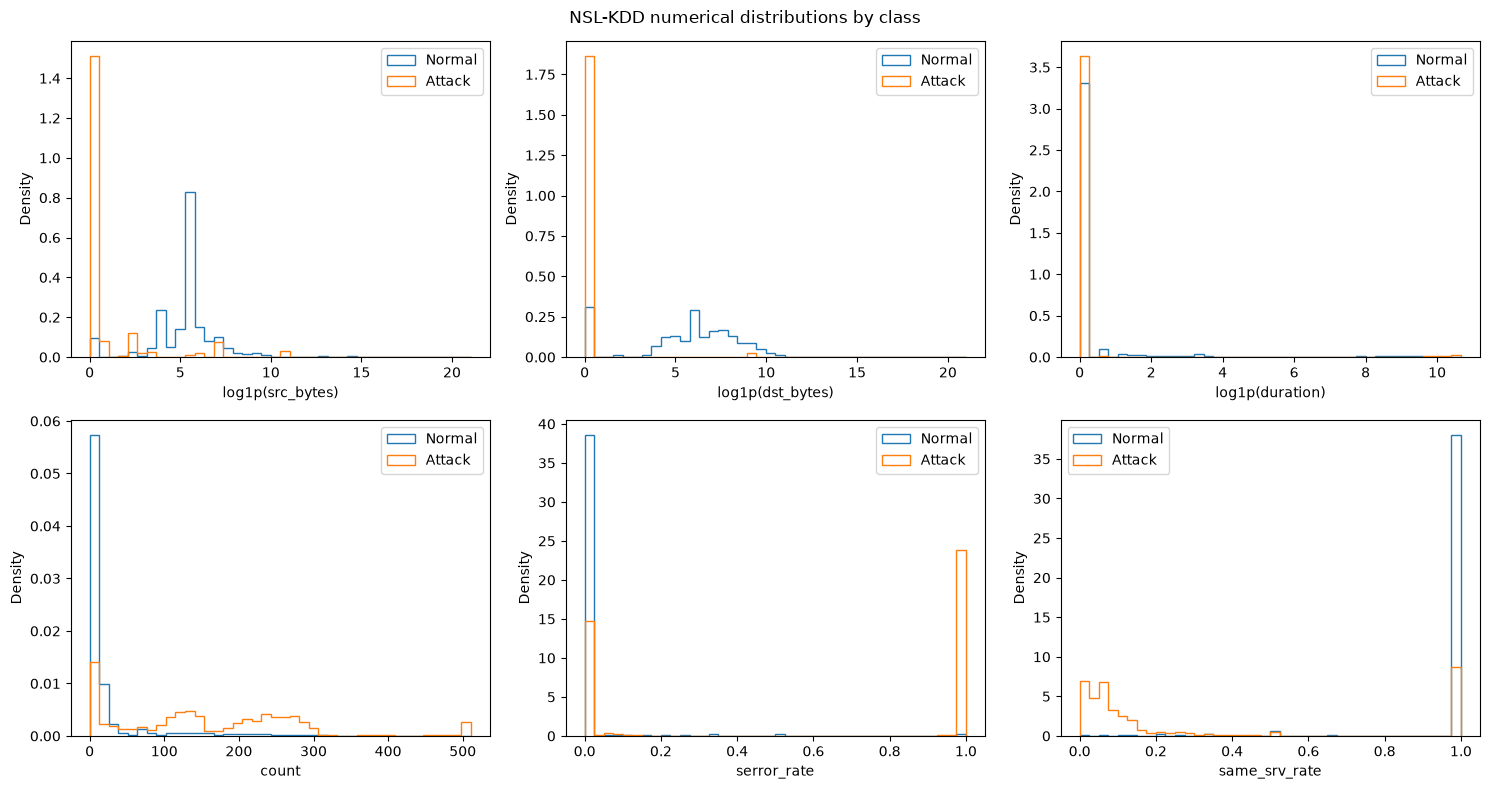

In [92]:
import numpy as np

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, c in zip(
    axes.flat, ["src_bytes", "dst_bytes", "duration", "count", "serror_rate", "same_srv_rate"]
):
    use_log = c in {"src_bytes", "dst_bytes", "duration"}
    values = [subset[c].to_numpy() for subset in [normal_df, attack_df]]
    if use_log:
        values = [np.log1p(v) for v in values]
    bins = np.histogram_bin_edges(np.concatenate(values), bins=40)
    for label, v, color in zip(["Normal", "Attack"], values, ["tab:blue", "tab:orange"]):
        ax.hist(v, bins=bins, density=True, histtype="step", label=label, color=color)
    ax.set_xlabel(f"log1p({c})" if use_log else c)
    ax.set_ylabel("Density")
    ax.legend()
fig.suptitle("NSL-KDD numerical distributions by class")
fig.tight_layout()
plt.show()

## Findings and next step

The following summary is calculated from the current CSV. Preserve original rows at this stage. Next, create reproducible development/validation splits before fitting vocabularies or transforms; use the catalogue to prepare separate GMM and TabDDPM inputs.

In [93]:
print(f"Normal: {normal_df.height:,}; attack: {attack_df.height:,}")
print(
    "Constant normal features:",
    feature_catalogue.filter(pl.col("constant_normal"))["feature"].to_list(),
)
print(f"Normal src_bytes zero fraction: {(normal_df['src_bytes'] == 0).mean():.2%}")
print("Observed normal su_attempted states:", normal_df["su_attempted"].unique().sort().to_list())
print("Attack-only category counts:")
display(category_frequencies.filter(pl.col("support") == "attack_only").group_by("feature").len())
print("Duplicate audit:", duplicate_summary)

Normal: 20,000; attack: 10,000
Constant normal features: ['wrong_fragment', 'num_outbound_cmds', 'is_host_login']
Normal src_bytes zero fraction: 5.10%
Observed normal su_attempted states: [0, 1, 2]
Attack-only category counts:


feature,len
str,u32
"""service""",41
"""flag""",2


Duplicate audit: {'exact_duplicate_extra_rows': 1, 'feature_duplicate_extra_rows': 1, 'feature_duplicate_groups': 1, 'conflicting_label_groups': 0}


## Step 2: development and validation splits

Use a fixed seed and an approximately 80/20 class-stratified split. Identical feature vectors form one group and remain in the same partition. Stratification operates on groups, so row proportions may differ slightly when duplicates are present. Conflicting labels within a feature group stop the split for review.

Validation contains both normal and attack rows. It measures held-out performance on the released data, not unseen attack families. Do not fit transformations or category mappings on validation or reuse the full-data exploratory statistics above as fitted parameters.

In [94]:
from sklearn.model_selection import train_test_split

SPLIT_SEED = 42
VALIDATION_FRACTION = 0.20


def make_development_split(frame, feature_columns, label_column, validation_fraction, seed):
    """Split exact feature groups; return original rows and a separate row manifest."""
    if not 0 < validation_fraction < 1:
        raise ValueError("validation_fraction must be between 0 and 1")
    reserved = {"source_row", "feature_group", "partition"}
    if reserved.intersection(frame.columns):
        raise ValueError("Input contains reserved split metadata columns")
    grouped = (
        frame.with_row_index("source_row")
        .group_by(feature_columns)
        .agg(
            pl.col("source_row").min().alias("feature_group"),
            pl.col(label_column).first().alias("group_label"),
            pl.col(label_column).n_unique().alias("n_labels"),
        )
        .sort("feature_group")
    )
    if grouped.filter(pl.col("n_labels") != 1).height:
        raise ValueError("Identical feature rows have conflicting labels; review before splitting")
    development_ids, validation_ids = train_test_split(
        grouped["feature_group"].to_numpy(),
        test_size=validation_fraction,
        random_state=seed,
        stratify=grouped["group_label"].to_numpy(),
    )
    group_assignments = grouped.select([*feature_columns, "feature_group"]).with_columns(
        pl.when(pl.col("feature_group").is_in(validation_ids.tolist()))
        .then(pl.lit("validation"))
        .otherwise(pl.lit("development"))
        .alias("partition")
    )
    assigned = (
        frame.with_row_index("source_row")
        .join(group_assignments, on=feature_columns, how="left", validate="m:1")
        .sort("source_row")
    )
    manifest = assigned.select("source_row", "feature_group", label_column, "partition")
    development = assigned.filter(pl.col("partition") == "development").select(frame.columns)
    validation = assigned.filter(pl.col("partition") == "validation").select(frame.columns)
    assert set(development_ids).isdisjoint(validation_ids)
    return development, validation, manifest


development_df, validation_df, split_manifest = make_development_split(
    train_df, features, LABEL, VALIDATION_FRACTION, SPLIT_SEED
)
development_normal_df = development_df.filter(pl.col(LABEL) == 0)
development_attack_df = development_df.filter(pl.col(LABEL) == 1)
validation_normal_df = validation_df.filter(pl.col(LABEL) == 0)
validation_attack_df = validation_df.filter(pl.col(LABEL) == 1)

# Explicit model interfaces exclude labels and split metadata from feature matrices.
X_generator_raw = development_normal_df.select(features)
X_boundary_raw = development_df.select(features)
y_boundary = development_df[LABEL]
X_validation_raw = validation_df.select(features)
y_validation = validation_df[LABEL]

split_summary = (
    split_manifest.group_by("partition", LABEL)
    .len()
    .sort("partition", LABEL)
    .with_columns(
        (pl.col("len") / pl.col("len").sum().over("partition")).alias("class_fraction"),
        (pl.col("len") / pl.col("len").sum().over(LABEL)).alias("fraction_of_class"),
    )
)
display(split_summary)
print(f"Generator fitting rows: {X_generator_raw.height:,} (normal only)")
print(f"Boundary fitting rows: {X_boundary_raw.height:,} (both classes)")
print(f"Validation rows: {X_validation_raw.height:,} (both classes)")

partition,is_anomaly,len,class_fraction,fraction_of_class
str,i64,u32,f64,f64
"""development""",0,16000,0.666694,0.8
"""development""",1,7999,0.333306,0.7999
"""validation""",0,4000,0.666556,0.2
"""validation""",1,2001,0.333444,0.2001


Generator fitting rows: 16,000 (normal only)
Boundary fitting rows: 23,999 (both classes)
Validation rows: 6,001 (both classes)


### Split integrity and development-only category support

Verify row coverage, group separation, feature overlap, class coverage, and repeatability. Report validation categories absent from development so the next step can define an unknown-category policy without learning a validation vocabulary. Generator support uses development normals; boundary support uses all development rows.

In [95]:
assert development_df.height + validation_df.height == train_df.height
assert development_df.schema == validation_df.schema == train_df.schema
assert split_manifest["source_row"].n_unique() == train_df.height
assert split_manifest["partition"].null_count() == 0
assert (
    split_manifest.group_by("feature_group")
    .agg(pl.col("partition").n_unique().alias("partitions"))["partitions"]
    .max()
    == 1
)
assert (
    development_df.select(features)
    .unique()
    .join(validation_df.select(features).unique(), on=features, how="inner")
    .height
    == 0
), "Feature rows overlap across partitions"
assert set(development_df[LABEL].unique().to_list()) == {0, 1}
assert set(validation_df[LABEL].unique().to_list()) == {0, 1}
assert X_generator_raw.columns == X_boundary_raw.columns == X_validation_raw.columns == features
assert development_normal_df[LABEL].eq(0).all()
_, _, repeated_manifest = make_development_split(
    train_df, features, LABEL, VALIDATION_FRACTION, SPLIT_SEED
)
assert split_manifest.equals(repeated_manifest), "Split is not reproducible"

support_rows = []
for c in CATEGORICAL:
    generator_support = set(development_normal_df[c].to_list())
    boundary_support = set(development_df[c].to_list())
    support_rows.append(
        {
            "feature": c,
            "development_normal_categories": len(generator_support),
            "development_all_categories": len(boundary_support),
            "validation_normal_absent_from_generator": sorted(
                set(validation_normal_df[c]) - generator_support
            ),
            "validation_all_absent_from_boundary": sorted(set(validation_df[c]) - boundary_support),
        }
    )
split_category_support = pl.DataFrame(support_rows)
with pl.Config(tbl_cols=6, fmt_str_lengths=80):
    display(split_category_support)
print("Passed coverage, leakage, class, schema, and reproducibility checks.")

feature,development_normal_categories,development_all_categories,validation_normal_absent_from_generator,validation_all_absent_from_boundary
str,i64,i64,list[str],list[str]
"""protocol_type""",3,3,[],[]
"""service""",25,66,"[""tim_i""]","[""tim_i""]"
"""flag""",9,11,[],[]


Passed coverage, leakage, class, schema, and reproducibility checks.


### Persist the raw splits

Save under `output/nsl_kdd/splits/` **(ignored by Git)**. CSV copies of each partition and the row manifest are also saved. Parquet partitions preserve the original columns, dtypes, and row order; the separate manifest maps each original zero-based CSV data-row index to its feature group and partition. JSON records the source checksum, seed, ratio, versions, feature order, and realized counts. Re-running overwrites these files using the current seed and source CSV.

**For models, should fit generator metadata and transforms on `development_normal_df` only. The boundary estimator uses `development_df`. Keep `validation_df` held out. Final submission generation will later refit the selected pipeline using the full released training data.**

In [96]:
import hashlib
import json

import sklearn

split_output = train_path.parents[2] / "output" / "nsl_kdd" / "splits"
split_output.mkdir(parents=True, exist_ok=True)
raw_partitions = {
    "development": development_df,
    "validation": validation_df,
    "development_normal": development_normal_df,
    "development_attack": development_attack_df,
}
for name, frame in raw_partitions.items():
    frame.write_parquet(split_output / f"{name}.parquet")
    frame.write_csv(split_output / f"{name}.csv")
split_manifest.write_parquet(split_output / "row_manifest.parquet")
split_manifest.write_csv(split_output / "row_manifest.csv")
split_metadata = {
    "source": str(train_path.relative_to(train_path.parents[2])),
    "source_sha256": hashlib.sha256(train_path.read_bytes()).hexdigest(),
    "source_rows": train_df.height,
    "seed": SPLIT_SEED,
    "requested_validation_fraction": VALIDATION_FRACTION,
    "actual_validation_fraction": validation_df.height / train_df.height,
    "method": "class-stratified train_test_split over exact feature groups",
    "group_id": "minimum zero-based source data-row index in each exact feature group",
    "feature_order": features,
    "label": LABEL,
    "versions": {"polars": pl.__version__, "scikit_learn": sklearn.__version__},
    "counts": split_summary.to_dicts(),
    "files": {name: f"{name}.parquet" for name in raw_partitions},
    "manifest": "row_manifest.parquet",
    "csv_files": {name: f"{name}.csv" for name in raw_partitions},
    "csv_manifest": "row_manifest.csv",
}
(split_output / "split_metadata.json").write_text(
    json.dumps(split_metadata, indent=2) + "\n", encoding="utf-8"
)
# Validate persisted artifacts before later steps consume them.
for name, frame in raw_partitions.items():
    assert pl.read_parquet(split_output / f"{name}.parquet").equals(frame)
assert pl.read_parquet(split_output / "row_manifest.parquet").equals(split_manifest)
print(f"Saved and verified split artifacts: {split_output}")

Saved and verified split artifacts: C:\Users\tanyi\OneDrive\Home Desktop\Documents\GitHub\cs5344-data-augmentation-for-anomaly-detection\output\nsl_kdd\splits


## Fit preprocessing metadata

Fit generator vocabularies, bounds, constants, and numerical transformers on **development normal rows only**. Fit separate boundary vocabularies on all development rows. Validation never contributes fitted parameters. Feature semantics come from the Step 1 catalogue, but its full-data empirical statistics are not reused.

Baseline policy: remove normal constants; retain binary and discrete states without numerical scaling; apply a Gaussian quantile transform when absolute skewness exceeds 2 and at least three distinct values are present; otherwise standardize active numerical features. This is an experimental baseline, not a guarantee that Gaussian diffusion preserves zero mass. Record zero fractions for a later zero-indicator experiment. Empirical normal min/max values are recorded separately from hard domain constraints.

In [97]:
import joblib
from sklearn.preprocessing import QuantileTransformer, StandardScaler

SKEW_THRESHOLD = 2.0
MAX_QUANTILES = 1000
numeric_transformers = {}
column_rules = {}
generator_vocabularies = {}
boundary_vocabularies = {}

for c in features:
    s = development_normal_df[c]
    kind = semantic_type(c)
    constant = s.n_unique() == 1
    rule = {
        "dtype": str(train_df.schema[c]),
        "semantic_type": kind,
        "constant_normal": constant,
        "constant_value": s[0] if constant else None,
        "n_unique_normal": s.n_unique(),
    }
    if c in CATEGORICAL:
        vocabulary = sorted(s.unique().to_list())
        generator_vocabularies[c] = vocabulary
        boundary_vocabularies[c] = sorted(development_df[c].unique().to_list())
        rule.update(
            transform="restore_constant" if constant else "categorical",
            vocabulary=vocabulary,
            cardinality=len(vocabulary),
            frequencies=dict(s.value_counts().iter_rows()),
            domain={"allowed_values": vocabulary, "basis": "development_normal_support"},
        )
    else:
        values = s.to_numpy().astype(np.float64)
        skewness = float(s.skew()) if not constant else None
        if skewness is not None and not np.isfinite(skewness):
            skewness = None
        domain = {"min": 0}
        if c in BINARY:
            domain = {"allowed_values": [0, 1]}
        elif c in DISCRETE:
            domain = {"allowed_values": DISCRETE[c]}
        elif c in RATES:
            domain = {"min": 0, "max": 1}
        rule.update(
            empirical_normal_bounds={"min": float(s.min()), "max": float(s.max())},
            domain=domain,
            integer_required=c in COUNTS or c in BINARY or c in DISCRETE,
            zero_fraction=float((s == 0).mean()),
            skewness=skewness,
            zero_indicator_candidate=not constant
            and kind in {"count", "continuous", "bounded_rate"}
            and 0.5 <= float((s == 0).mean()) < 1,
        )
        if constant:
            rule["transform"] = "restore_constant"
        elif c in BINARY or c in DISCRETE:
            rule["transform"] = "identity_discrete"
        else:
            use_quantile = (
                skewness is not None and abs(skewness) > SKEW_THRESHOLD and s.n_unique() > 2
            )
            transformer = (
                QuantileTransformer(
                    n_quantiles=min(MAX_QUANTILES, len(values)),
                    output_distribution="normal",
                    subsample=len(values),
                    random_state=SPLIT_SEED,
                )
                if use_quantile
                else StandardScaler()
            )
            transformer.fit(values.reshape(-1, 1))
            numeric_transformers[c] = transformer
            rule["transform"] = "quantile_normal" if use_quantile else "standard"
    column_rules[c] = rule

constant_features = [c for c in features if column_rules[c]["constant_normal"]]
active_numerical_features = [c for c in numerical if c in numeric_transformers]
active_discrete_features = [
    c for c in features if column_rules[c]["transform"] == "identity_discrete"
]
active_categorical_features = [c for c in CATEGORICAL if c not in constant_features]
preprocessing_summary = pl.DataFrame(
    [
        {
            "feature": c,
            "semantic_type": column_rules[c]["semantic_type"],
            "transform": column_rules[c]["transform"],
            "constant_normal": column_rules[c]["constant_normal"],
            "zero_fraction": column_rules[c].get("zero_fraction"),
            "skewness": column_rules[c].get("skewness"),
        }
        for c in features
    ]
)
with pl.Config(tbl_rows=50):
    display(preprocessing_summary)
print("Normal fitting rows:", development_normal_df.height)
print("Constant features:", constant_features)
print("Fitted numerical transformers:", len(numeric_transformers))

feature,semantic_type,transform,constant_normal,zero_fraction,skewness
str,str,str,bool,f64,f64
"""duration""","""count""","""quantile_normal""",false,0.8826875,11.779446
"""src_bytes""","""count""","""quantile_normal""",false,0.0501875,117.7896
"""dst_bytes""","""count""","""quantile_normal""",false,0.162875,87.184812
"""land""","""binary""","""identity_discrete""",false,0.999875,89.425948
"""wrong_fragment""","""count""","""restore_constant""",true,1.0,null
"""urgent""","""count""","""standard""",false,0.999875,89.425948
"""hot""","""count""","""quantile_normal""",false,0.981,11.843713
"""num_failed_logins""","""count""","""quantile_normal""",false,0.99875,43.213141
"""logged_in""","""binary""","""identity_discrete""",false,0.2879375,-0.936668


Normal fitting rows: 16000
Constant features: ['wrong_fragment', 'num_outbound_cmds', 'is_host_login']
Fitted numerical transformers: 30


### Category encoding and unknown values

Generator codes are contiguous nonnegative indices into normal vocabularies. Encoding an unknown generator category raises an error: it must not become a synthetic normal category. Boundary vocabularies include development attacks; unknown boundary categories receive **-1**, intended as a missing-category code for the later LightGBM adapter. No synthetic unknown category is added to generator cardinalities. A downstream evaluation encoder needs its own explicit unknown policy when implemented.

In [98]:
def encode_categories(frame, vocabularies, allow_unknown=False):
    """Return category codes without fitting or extending a vocabulary."""
    encoded = []
    for c, vocabulary in vocabularies.items():
        mapping = {value: index for index, value in enumerate(vocabulary)}
        unknown = sorted(set(frame[c].to_list()) - set(vocabulary))
        if unknown and not allow_unknown:
            raise ValueError(f"Unknown generator categories in {c}: {unknown}")
        encoded.append(frame[c].replace_strict(mapping, default=-1, return_dtype=pl.Int64).alias(c))
    return pl.DataFrame(encoded)


def decode_generator_categories(encoded):
    decoded = []
    for c, vocabulary in generator_vocabularies.items():
        s = encoded[c]
        if (
            s.null_count()
            or not s.dtype.is_integer()
            or not s.is_between(0, len(vocabulary) - 1).all()
        ):
            raise ValueError(f"Invalid generator category codes in {c}")
        decoded.append(
            s.replace_strict(dict(enumerate(vocabulary)), return_dtype=pl.String).alias(c)
        )
    return pl.DataFrame(decoded)


unknown_category_report = pl.DataFrame(
    [
        {
            "feature": c,
            "generator_cardinality": len(generator_vocabularies[c]),
            "boundary_cardinality": len(boundary_vocabularies[c]),
            "validation_unknown_boundary_rows": int(
                (~validation_df[c].is_in(boundary_vocabularies[c])).sum()
            ),
            "validation_unknown_normal_rows": int(
                (~validation_normal_df[c].is_in(generator_vocabularies[c])).sum()
            ),
        }
        for c in CATEGORICAL
    ]
)
display(unknown_category_report)

feature,generator_cardinality,boundary_cardinality,validation_unknown_boundary_rows,validation_unknown_normal_rows
str,i64,i64,i64,i64
"""protocol_type""",3,3,0,0
"""service""",25,66,3,3
"""flag""",9,11,0,0


### Verify the fitted rules

Check category round-trips, finite numerical representations, inverse-transform reconstruction, fitting-row provenance, constants, and the unseen-category policy. Counts are compared after rounding on inverse transform. Gaussian quantile transforms interpolate empirical quantiles; use tolerance for continuous numerical reconstruction.

In [99]:
assert development_normal_df[LABEL].eq(0).all()
assert set(numeric_transformers) == set(active_numerical_features)
for c, vocabulary in generator_vocabularies.items():
    assert vocabulary == sorted(development_normal_df[c].unique().to_list())
    assert boundary_vocabularies[c] == sorted(development_df[c].unique().to_list())
encoded_normal = encode_categories(development_normal_df, generator_vocabularies)
assert decode_generator_categories(encoded_normal).equals(development_normal_df.select(CATEGORICAL))
for c, transformer in numeric_transformers.items():
    original = development_normal_df[c].to_numpy().astype(np.float64).reshape(-1, 1)
    encoded = transformer.transform(original)
    restored = transformer.inverse_transform(encoded)
    assert np.isfinite(encoded).all() and np.isfinite(restored).all(), c
    if column_rules[c]["integer_required"]:
        restored = np.rint(restored)
    assert np.allclose(restored, original, rtol=1e-7, atol=1e-7), f"Round-trip mismatch: {c}"
    if isinstance(transformer, StandardScaler):
        assert transformer.n_samples_seen_ == development_normal_df.height
    else:
        assert transformer.quantiles_[0, 0] == original.min()
        assert transformer.quantiles_[-1, 0] == original.max()
for c in constant_features:
    assert (development_normal_df[c] == column_rules[c]["constant_value"]).all()

# Construct an unseen token without borrowing any validation category for fitting.
probe = (
    development_normal_df.select(CATEGORICAL)
    .head(1)
    .with_columns(pl.lit("__UNSEEN_PROTOCOL_TEST__").alias("protocol_type"))
)
assert "__UNSEEN_PROTOCOL_TEST__" not in generator_vocabularies["protocol_type"]
assert encode_categories(probe, boundary_vocabularies, allow_unknown=True)["protocol_type"][0] == -1
try:
    encode_categories(probe, generator_vocabularies)
except ValueError:
    pass
else:
    raise AssertionError("Generator accepted an unseen category")
print("Passed fitted-support, numerical/category round-trip, and unknown-category checks.")

Passed fitted-support, numerical/category round-trip, and unknown-category checks.


### Save the preprocessing artifacts

Write JSON metadata and fitted numerical transformers under `output/nsl_kdd/preprocessing/`. The metadata links these rules to the source CSV and exact split assignment checksum. Joblib files are intended for this project's Python environment; load only trusted artifacts. Running this cell overwrites the current development artifacts. No generator training or validation fitting occurs here.

In [100]:
preprocessing_output = train_path.parents[2] / "output" / "nsl_kdd" / "preprocessing"
preprocessing_output.mkdir(parents=True, exist_ok=True)
preprocessing_metadata = {
    "artifact_version": 1,
    "fit_partition": "development_normal",
    "fit_rows": development_normal_df.height,
    "boundary_fit_partition": "development",
    "boundary_fit_rows": development_df.height,
    "source_sha256": split_metadata["source_sha256"],
    "split_manifest_sha256": hashlib.sha256(
        (split_output / "row_manifest.parquet").read_bytes()
    ).hexdigest(),
    "split_seed": SPLIT_SEED,
    "validation_fraction": VALIDATION_FRACTION,
    "feature_order": features,
    "label": LABEL,
    "constant_features": constant_features,
    "active_numerical_features": active_numerical_features,
    "active_discrete_features": active_discrete_features,
    "active_categorical_features": active_categorical_features,
    "columns": column_rules,
    "generator_vocabularies": generator_vocabularies,
    "boundary_vocabularies": boundary_vocabularies,
    "category_encoding": "zero-based index in stored vocabulary order",
    "unknown_policy": {"generator": "error", "boundary": "code -1; treat as missing"},
    "transform_policy": {
        "absolute_skew_threshold": SKEW_THRESHOLD,
        "max_quantiles": MAX_QUANTILES,
        "quantile_subsample": development_normal_df.height,
        "zero_indicators": "candidates recorded only; not applied in this baseline",
        "empirical_bounds": "observed normal support; not hard physical constraints",
    },
    "versions": {
        "polars": pl.__version__,
        "scikit_learn": sklearn.__version__,
        "numpy": np.__version__,
        "joblib": joblib.__version__,
    },
}
metadata_path = preprocessing_output / "metadata.json"
transformers_path = preprocessing_output / "numeric_transformers.joblib"
metadata_path.write_text(
    json.dumps(preprocessing_metadata, indent=2, allow_nan=False) + "\n", encoding="utf-8"
)
joblib.dump(numeric_transformers, transformers_path)
assert json.loads(metadata_path.read_text(encoding="utf-8")) == preprocessing_metadata
loaded_transformers = joblib.load(transformers_path)
assert set(loaded_transformers) == set(numeric_transformers)
for c, transformer in loaded_transformers.items():
    sample = development_normal_df[c].head(10).to_numpy().reshape(-1, 1)
    assert np.array_equal(transformer.transform(sample), numeric_transformers[c].transform(sample))
print(f"Saved and verified preprocessing artifacts: {preprocessing_output}")

Saved and verified preprocessing artifacts: C:\Users\tanyi\OneDrive\Home Desktop\Documents\GitHub\cs5344-data-augmentation-for-anomaly-detection\output\nsl_kdd\preprocessing


## Step 4: prepare GMM and TabDDPM inputs

Build both representations from the saved Step 3 artifacts, without fitting new transformers. Only development normals become generator inputs. Keep the baseline numerical transformations from Step 3: zero-indicator candidates remain recorded for a separate experiment rather than changing the fitted representation here. Neither labels nor source-row identifiers are model features. Validation stays in its raw held-out representation.

GMM receives float64 transformed numericals and a row-aligned discrete donor table. After GMM fitting, component assignments can be used to select whole donor tuples and preserve dependencies among discrete columns. TabDDPM receives float32 numericals and int64 categorical codes, including binary indicators and `su_attempted`. This step prepares data; generator fitting and component assignment come later.

In [101]:
# Use persisted rules so these inputs can be reproduced by later training scripts.
input_rules = json.loads(metadata_path.read_text(encoding="utf-8"))
input_transformers = joblib.load(transformers_path)
assert input_rules["source_sha256"] == hashlib.sha256(train_path.read_bytes()).hexdigest()
assert (
    input_rules["split_manifest_sha256"]
    == hashlib.sha256((split_output / "row_manifest.parquet").read_bytes()).hexdigest()
)
assert input_rules["feature_order"] == features
assert input_rules["fit_partition"] == "development_normal"
assert input_rules["fit_rows"] == development_normal_df.height

model_numeric_columns = input_rules["active_numerical_features"]
model_discrete_columns = [
    c
    for c in features
    if c in input_rules["active_categorical_features"]
    or c in input_rules["active_discrete_features"]
]
model_constant_columns = input_rules["constant_features"]
assert set(model_numeric_columns).isdisjoint(model_discrete_columns)
assert set(model_numeric_columns).isdisjoint(model_constant_columns)
assert set(model_discrete_columns).isdisjoint(model_constant_columns)
assert set([*model_numeric_columns, *model_discrete_columns, *model_constant_columns]) == set(
    features
)
assert set(input_transformers) == set(model_numeric_columns)

# IDs refer to original CSV data rows, not a reset development row index.
generator_row_manifest = (
    split_manifest.filter((pl.col("partition") == "development") & (pl.col(LABEL) == 0))
    .sort("source_row")
    .select("source_row", "feature_group")
)
source_rows = generator_row_manifest["source_row"].to_numpy().astype(np.int64)
assert train_df[source_rows.tolist()].equals(development_normal_df)

numerical_matrix = np.ascontiguousarray(
    np.column_stack(
        [
            input_transformers[c]
            .transform(development_normal_df[c].to_numpy().astype(np.float64).reshape(-1, 1))
            .ravel()
            for c in model_numeric_columns
        ]
    ),
    dtype=np.float64,
)
gmm_X = numerical_matrix
tabddpm_X_num = np.ascontiguousarray(numerical_matrix, dtype=np.float32)

# Preserve raw discrete tuples for GMM's future component-conditional donor sampler.
gmm_donors = development_normal_df.select(model_discrete_columns)
model_discrete_vocabularies = {
    c: input_rules["generator_vocabularies"][c]
    if c in input_rules["generator_vocabularies"]
    else sorted(development_normal_df[c].unique().to_list())
    for c in model_discrete_columns
}
# Numeric discrete support also comes solely from development normals.
# Domain-valid states absent from fitting rows must not become new normal states.
encoded_discrete = encode_categories(development_normal_df, model_discrete_vocabularies)
tabddpm_X_cat = np.ascontiguousarray(encoded_discrete.to_numpy(), dtype=np.int64)
tabddpm_cardinalities = np.array(
    [len(model_discrete_vocabularies[c]) for c in model_discrete_columns], dtype=np.int64
)

model_input_summary = pl.DataFrame(
    [
        {
            "input": "GMM numerical",
            "rows": gmm_X.shape[0],
            "columns": gmm_X.shape[1],
            "dtype": str(gmm_X.dtype),
        },
        {
            "input": "GMM discrete donors",
            "rows": gmm_donors.height,
            "columns": gmm_donors.width,
            "dtype": "original column types",
        },
        {
            "input": "TabDDPM numerical",
            "rows": tabddpm_X_num.shape[0],
            "columns": tabddpm_X_num.shape[1],
            "dtype": str(tabddpm_X_num.dtype),
        },
        {
            "input": "TabDDPM categorical",
            "rows": tabddpm_X_cat.shape[0],
            "columns": tabddpm_X_cat.shape[1],
            "dtype": str(tabddpm_X_cat.dtype),
        },
    ]
)
display(model_input_summary)
display(
    pl.DataFrame(
        [
            {
                "position": i,
                "feature": c,
                "vocabulary": str(model_discrete_vocabularies[c]),
                "cardinality": int(tabddpm_cardinalities[i]),
            }
            for i, c in enumerate(model_discrete_columns)
        ]
    )
)

input,rows,columns,dtype
str,i64,i64,str
"""GMM numerical""",16000,30,"""float64"""
"""GMM discrete donors""",16000,8,"""original column types"""
"""TabDDPM numerical""",16000,30,"""float32"""
"""TabDDPM categorical""",16000,8,"""int64"""


position,feature,vocabulary,cardinality
i64,str,str,i64
0,"""land""","""[0, 1]""",2
1,"""logged_in""","""[0, 1]""",2
2,"""root_shell""","""[0, 1]""",2
3,"""su_attempted""","""[0, 1, 2]""",3
4,"""is_guest_login""","""[0, 1]""",2
5,"""protocol_type""","""['icmp', 'tcp', 'udp']""",3
6,"""service""","""['IRC', 'X11', 'auth', 'domain…",25
7,"""flag""","""['OTH', 'REJ', 'RSTO', 'RSTR',…",9


### Verify model representations

Check finite values, dtypes, category ranges and decoding, feature coverage, row alignment, and transformer reuse. The numerical matrices share column order but use different precision for their respective models. Constants are excluded from both and retained in Step 3 metadata for later reconstruction.

In [102]:
assert (
    gmm_X.shape == tabddpm_X_num.shape == (development_normal_df.height, len(model_numeric_columns))
)
assert tabddpm_X_cat.shape == (development_normal_df.height, len(model_discrete_columns))
assert gmm_donors.height == len(source_rows) == development_normal_df.height
assert gmm_X.dtype == np.float64 and tabddpm_X_num.dtype == np.float32
assert tabddpm_X_cat.dtype == np.int64
assert np.isfinite(gmm_X).all() and np.isfinite(tabddpm_X_num).all()
assert np.array_equal(tabddpm_X_num, gmm_X.astype(np.float32))
for i, c in enumerate(model_numeric_columns):
    expected = (
        input_transformers[c]
        .transform(development_normal_df[c].to_numpy().astype(np.float64).reshape(-1, 1))
        .ravel()
    )
    assert np.array_equal(gmm_X[:, i], expected), c
for i, c in enumerate(model_discrete_columns):
    codes = tabddpm_X_cat[:, i]
    vocabulary = model_discrete_vocabularies[c]
    assert (codes >= 0).all() and (codes < tabddpm_cardinalities[i]).all(), c
    decoded = pl.Series(
        c, [vocabulary[int(code)] for code in codes], dtype=development_normal_df.schema[c]
    )
    assert decoded.equals(development_normal_df[c]), f"Discrete round-trip mismatch: {c}"
assert gmm_donors.equals(train_df[source_rows.tolist()].select(model_discrete_columns))
assert LABEL not in model_numeric_columns and LABEL not in model_discrete_columns
assert source_rows.size == np.unique(source_rows).size
print("Passed model-input dtype, finite-value, code-range, decoding, and alignment checks.")

Passed model-input dtype, finite-value, code-range, decoding, and alignment checks.


### Save model-ready inputs

Write under `output/nsl_kdd/model_inputs/`. `gmm_inputs.npz` stores `X` and separate `source_row` IDs. `tabddpm_inputs.npz` stores `X_num`, `X_cat`, categorical cardinalities, and separate `source_row` IDs. These IDs are provenance, not training features. `gmm_donors.parquet` shares the exact array row order; `generator_rows.parquet` records source rows and duplicate groups.

`metadata.json` stores feature order, discrete vocabularies, array dimensions, constant rules, and checksums of the fitted preprocessing artifacts. TabDDPM model dimensions/cardinalities must come from this metadata. These are adapter inputs; a selected training implementation may require its own file layout. Later decoding will restore constants and original feature order before boundary filtering.

CSV copies include named numerical/categorical columns and a `source_row` column for alignment. Exclude `source_row` from model features. CSV does not preserve array dtypes; use NPZ files for training or restore the dtypes recorded in metadata.


In [103]:
model_input_output = train_path.parents[2] / "output" / "nsl_kdd" / "model_inputs"
model_input_output.mkdir(parents=True, exist_ok=True)
np.savez_compressed(model_input_output / "gmm_inputs.npz", X=gmm_X, source_row=source_rows)
np.savez_compressed(
    model_input_output / "tabddpm_inputs.npz",
    X_num=tabddpm_X_num,
    X_cat=tabddpm_X_cat,
    categorical_cardinalities=tabddpm_cardinalities,
    source_row=source_rows,
)
gmm_donors.write_parquet(model_input_output / "gmm_donors.parquet")
generator_row_manifest.write_parquet(model_input_output / "generator_rows.parquet")
# CSV copies carry named columns and separate provenance IDs.
source_row_series = pl.Series("source_row", source_rows)
csv_model_frames = {
    "gmm_inputs": pl.DataFrame(gmm_X, schema=model_numeric_columns, orient="row").insert_column(
        0, source_row_series
    ),
    "tabddpm_numerical": pl.DataFrame(
        tabddpm_X_num, schema=model_numeric_columns, orient="row"
    ).insert_column(0, source_row_series),
    "tabddpm_categorical": pl.DataFrame(
        tabddpm_X_cat, schema=model_discrete_columns, orient="row"
    ).insert_column(0, source_row_series),
    "gmm_donors": gmm_donors.clone().insert_column(0, source_row_series),
    "generator_rows": generator_row_manifest,
}
for name, frame in csv_model_frames.items():
    frame.write_csv(model_input_output / f"{name}.csv")

model_input_metadata = {
    "artifact_version": 1,
    "fit_partition": "development_normal",
    "rows": development_normal_df.height,
    "source_sha256": input_rules["source_sha256"],
    "split_manifest_sha256": input_rules["split_manifest_sha256"],
    "preprocessing_metadata_sha256": hashlib.sha256(metadata_path.read_bytes()).hexdigest(),
    "numeric_transformers_sha256": hashlib.sha256(transformers_path.read_bytes()).hexdigest(),
    "preprocessing_metadata": "../preprocessing/metadata.json",
    "numeric_transformers": "../preprocessing/numeric_transformers.joblib",
    "feature_order": features,
    "numerical_columns": model_numeric_columns,
    "discrete_columns": model_discrete_columns,
    "discrete_vocabularies": model_discrete_vocabularies,
    "categorical_cardinalities": tabddpm_cardinalities.tolist(),
    "constant_values": {
        c: input_rules["columns"][c]["constant_value"] for c in model_constant_columns
    },
    "zero_indicator_policy": "baseline; not applied",
    "gmm": {
        "file": "gmm_inputs.npz",
        "training_key": "X",
        "shape": list(gmm_X.shape),
        "dtype": str(gmm_X.dtype),
        "donors": "gmm_donors.parquet",
        "donor_sampling": "whole discrete tuples conditional on fitted component; not yet fitted",
    },
    "tabddpm": {
        "file": "tabddpm_inputs.npz",
        "numerical_key": "X_num",
        "categorical_key": "X_cat",
        "numerical_shape": list(tabddpm_X_num.shape),
        "categorical_shape": list(tabddpm_X_cat.shape),
        "numerical_dtype": str(tabddpm_X_num.dtype),
        "categorical_dtype": str(tabddpm_X_cat.dtype),
        "unknown_categories": "error; no unknown category trained",
    },
    "provenance": {
        "manifest": "generator_rows.parquet",
        "npz_key": "source_row",
        "row_order": "ascending original CSV source row",
        "model_feature": False,
    },
    "versions": input_rules["versions"],
    "csv_files": {name: f"{name}.csv" for name in csv_model_frames},
    "csv_source_row_policy": "provenance only; exclude source_row from training features",
}
input_metadata_path = model_input_output / "metadata.json"
input_metadata_path.write_text(
    json.dumps(model_input_metadata, indent=2, allow_nan=False) + "\n", encoding="utf-8"
)
assert json.loads(input_metadata_path.read_text(encoding="utf-8")) == model_input_metadata
with np.load(model_input_output / "gmm_inputs.npz", allow_pickle=False) as stored:
    assert np.array_equal(stored["X"], gmm_X)
    assert np.array_equal(stored["source_row"], source_rows)
with np.load(model_input_output / "tabddpm_inputs.npz", allow_pickle=False) as stored:
    assert np.array_equal(stored["X_num"], tabddpm_X_num)
    assert np.array_equal(stored["X_cat"], tabddpm_X_cat)
    assert np.array_equal(stored["categorical_cardinalities"], tabddpm_cardinalities)
    assert np.array_equal(stored["source_row"], source_rows)
assert pl.read_parquet(model_input_output / "gmm_donors.parquet").equals(gmm_donors)
assert pl.read_parquet(model_input_output / "generator_rows.parquet").equals(generator_row_manifest)
print(f"Saved and verified model inputs: {model_input_output}")

Saved and verified model inputs: C:\Users\tanyi\OneDrive\Home Desktop\Documents\GitHub\cs5344-data-augmentation-for-anomaly-detection\output\nsl_kdd\model_inputs


## Step 5: reusable decoding utilities

`utils.decoding.TabularDecoder` loads saved artifacts, inverts numerical transforms, decodes categorical/binary states, restores constants, rounds counts, and returns original feature columns/dtypes. Domain bounds are enforced; clipping to empirical normal bounds is enabled by default and can be disabled with `clip_to_normal_bounds=False`. Invalid codes, nonfinite inputs, and misaligned donors are rejected.

The calls below reconstruct development inputs to verify the interface; these are not generated synthetic samples. During GMM generation, supply one complete donor tuple selected conditional on the sampled component for each numerical sample. Decode before passing candidates to the boundary classifier. Labels and submission IDs are not included.
Float32 quantile coordinates can amplify reconstruction error in extreme tails (about 0.01% for the largest byte values here); integer rounding adds small count differences. GMM float64 reconstruction is checked more tightly.


In [104]:
import sys

# Allow importing project utilities when the kernel starts in this notebook folder.
project_root = train_path.parents[2]
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from utils import TabularDecoder

decoder = TabularDecoder.from_directory(model_input_output)
decoded_gmm = decoder.decode_gmm(gmm_X, gmm_donors)
decoded_tabddpm = decoder.decode_tabddpm(tabddpm_X_num, tabddpm_X_cat)
assert decoded_gmm.schema == decoded_tabddpm.schema == X_generator_raw.schema
assert decoded_gmm.columns == features
for c in features:
    if c in CATEGORICAL or c in model_discrete_columns or c in model_constant_columns:
        assert decoded_gmm[c].equals(X_generator_raw[c]), c
        assert decoded_tabddpm[c].equals(X_generator_raw[c]), c
    else:
        original = X_generator_raw[c].to_numpy()
        assert np.allclose(decoded_gmm[c].to_numpy(), original, rtol=1e-7, atol=1e-7), c
        # Float32 diffusion inputs can lose numerical precision before inverse transform.
        atol = 2.0 if column_rules[c]["integer_required"] else 1e-5
        assert np.allclose(decoded_tabddpm[c].to_numpy(), original, rtol=2e-4, atol=atol), c
print("Both reusable decoders passed reconstruction and schema checks.")
display(decoded_tabddpm.head())

Both reusable decoders passed reconstruction and schema checks.


duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,protocol_type,service,flag
i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,str
0,810,332,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,3,1,0.0,0.0,0.0,0.0,0.33,0.67,0.0,85,157,0.58,0.06,0.01,0.01,0.0,0.0,0.0,0.0,"""tcp""","""smtp""","""SF"""
0,516,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,271,271,0.0,0.0,0.0,0.0,1.0,0.0,0.0,255,255,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,"""udp""","""other""","""SF"""
0,223,187,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,7,9,0.0,0.0,0.0,0.0,1.0,0.0,0.33,7,255,1.0,0.0,0.14,0.06,0.0,0.0,0.0,0.0,"""tcp""","""http""","""SF"""
0,211,1628,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,2,2,0.0,0.0,0.0,0.0,1.0,0.0,0.0,2,2,1.0,0.0,0.5,0.0,0.0,0.0,0.0,0.0,"""tcp""","""http""","""SF"""
0,45,132,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,67,145,0.0,0.0,0.0,0.0,1.0,0.0,0.01,255,173,0.68,0.02,0.0,0.0,0.0,0.0,0.0,0.0,"""udp""","""domain_u""","""SF"""


## Artifact validation and audit export (Verify other members using the correct inputs)

Reload saved artifacts and verify source/split provenance, complete row coverage, no feature overlap, normal-only generator inputs, numerical and categorical representations, donor alignment, and decoder reconstruction. Export the exploratory audit tables as CSV and Parquet, plus a JSON check report and file inventory. Full-data exploratory statistics remain separate from fitted normal-development rules.

Passing these checks means the preprocessing artifacts are internally consistent; it does not measure synthetic-data quality or downstream AUPRC. No generators or boundary classifiers are trained in this step.

In [105]:
saved_development = pl.read_parquet(split_output / "development.parquet")
saved_validation = pl.read_parquet(split_output / "validation.parquet")
saved_normal = pl.read_parquet(split_output / "development_normal.parquet")
saved_attack = pl.read_parquet(split_output / "development_attack.parquet")
saved_manifest = pl.read_parquet(split_output / "row_manifest.parquet")
saved_preprocessing = json.loads(metadata_path.read_text(encoding="utf-8"))
saved_input_metadata = json.loads(input_metadata_path.read_text(encoding="utf-8"))
saved_decoder = TabularDecoder.from_directory(model_input_output)
saved_donors = pl.read_parquet(model_input_output / "gmm_donors.parquet")
saved_generator_rows = pl.read_parquet(model_input_output / "generator_rows.parquet")
with np.load(model_input_output / "gmm_inputs.npz", allow_pickle=False) as arrays:
    saved_gmm = arrays["X"].copy()
    saved_gmm_rows = arrays["source_row"].copy()
with np.load(model_input_output / "tabddpm_inputs.npz", allow_pickle=False) as arrays:
    saved_num = arrays["X_num"].copy()
    saved_cat = arrays["X_cat"].copy()
    saved_cardinalities = arrays["categorical_cardinalities"].copy()
    saved_tab_rows = arrays["source_row"].copy()

artifact_checks = []


def record_check(name, passed):
    artifact_checks.append({"check": name, "passed": bool(passed)})


record_check(
    "source_checksum",
    saved_preprocessing["source_sha256"] == hashlib.sha256(train_path.read_bytes()).hexdigest(),
)
record_check(
    "split_checksum",
    saved_preprocessing["split_manifest_sha256"]
    == hashlib.sha256((split_output / "row_manifest.parquet").read_bytes()).hexdigest(),
)
record_check(
    "manifest_coverage",
    saved_manifest["source_row"].sort().to_list() == list(range(train_df.height)),
)
record_check(
    "manifest_partitions",
    set(saved_manifest["partition"].to_list()) == {"development", "validation"},
)
for partition, frame in [("development", saved_development), ("validation", saved_validation)]:
    row_ids = (
        saved_manifest.filter(pl.col("partition") == partition)
        .sort("source_row")["source_row"]
        .to_list()
    )
    record_check(f"{partition}_source_alignment", frame.equals(train_df[row_ids]))
    record_check(f"{partition}_both_classes", set(frame[LABEL].to_list()) == {0, 1})
record_check(
    "duplicate_groups_kept_together",
    saved_manifest.group_by("feature_group").agg(pl.col("partition").n_unique())["partition"].max()
    == 1,
)
record_check(
    "no_feature_overlap",
    saved_development.select(features)
    .unique()
    .join(saved_validation.select(features).unique(), on=features, how="inner")
    .height
    == 0,
)
record_check("normal_subset", saved_normal.equals(saved_development.filter(pl.col(LABEL) == 0)))
record_check("attack_subset", saved_attack.equals(saved_development.filter(pl.col(LABEL) == 1)))
record_check(
    "normal_fit_provenance",
    saved_preprocessing["fit_partition"] == "development_normal"
    and saved_preprocessing["fit_rows"] == saved_normal.height,
)
record_check(
    "schema_and_feature_order",
    saved_normal.schema == train_df.schema and saved_input_metadata["feature_order"] == features,
)
record_check(
    "model_row_ids",
    np.array_equal(saved_gmm_rows, saved_tab_rows)
    and np.array_equal(saved_gmm_rows, saved_generator_rows["source_row"].to_numpy()),
)
record_check("model_source_alignment", saved_normal.equals(train_df[saved_gmm_rows.tolist()]))
record_check(
    "gmm_donors_aligned",
    saved_donors.equals(saved_normal.select(saved_input_metadata["discrete_columns"])),
)
record_check(
    "array_shapes",
    saved_gmm.shape
    == saved_num.shape
    == (saved_normal.height, len(saved_input_metadata["numerical_columns"]))
    and saved_cat.shape == (saved_normal.height, len(saved_input_metadata["discrete_columns"])),
)
record_check(
    "array_dtypes",
    saved_gmm.dtype == np.float64 and saved_num.dtype == np.float32 and saved_cat.dtype == np.int64,
)
record_check("finite_model_inputs", np.isfinite(saved_gmm).all() and np.isfinite(saved_num).all())
record_check(
    "shared_numeric_representation", np.array_equal(saved_num, saved_gmm.astype(np.float32))
)
record_check(
    "cardinalities",
    saved_cardinalities.tolist() == saved_input_metadata["categorical_cardinalities"],
)
for i, c in enumerate(saved_input_metadata["numerical_columns"]):
    expected = (
        saved_decoder.transformers[c]
        .transform(saved_normal[c].to_numpy().astype(np.float64).reshape(-1, 1))
        .ravel()
    )
    record_check(f"saved_transform:{c}", np.array_equal(saved_gmm[:, i], expected))
for i, c in enumerate(saved_input_metadata["discrete_columns"]):
    vocabulary = saved_input_metadata["discrete_vocabularies"][c]
    record_check(f"normal_vocabulary:{c}", vocabulary == sorted(saved_normal[c].unique().to_list()))
    record_check(
        f"valid_codes:{c}",
        (saved_cat[:, i] >= 0).all() and (saved_cat[:, i] < len(vocabulary)).all(),
    )

# Reconstruct arrays read from disk rather than relying on prior in-memory decoding.
reconstruction_rows = []
for engine, decoded in [
    ("gmm", saved_decoder.decode_gmm(saved_gmm, saved_donors)),
    ("tabddpm", saved_decoder.decode_tabddpm(saved_num, saved_cat)),
]:
    record_check(f"decoded_schema:{engine}", decoded.schema == saved_normal.select(features).schema)
    for c in features:
        if c in numerical:
            original = saved_normal[c].to_numpy().astype(np.float64)
            restored = decoded[c].to_numpy().astype(np.float64)
            error = np.abs(restored - original)
            integer = saved_preprocessing["columns"][c]["integer_required"]
            atol = (2.0 if integer else 1e-5) if engine == "tabddpm" else 1e-7
            rtol = 2e-4 if engine == "tabddpm" else 1e-7
            reconstruction_rows.append(
                {
                    "engine": engine,
                    "feature": c,
                    "max_absolute_error": float(error.max()),
                    "mean_absolute_error": float(error.mean()),
                    "atol": atol,
                    "rtol": rtol,
                }
            )
            record_check(
                f"reconstruction:{engine}:{c}",
                np.allclose(restored, original, rtol=rtol, atol=atol),
            )
        else:
            record_check(f"reconstruction:{engine}:{c}", decoded[c].equals(saved_normal[c]))

# Verify all CSV copies with recorded types; CSV itself does not retain dtype metadata.
for folder, frames in [
    (split_output, {**raw_partitions, "row_manifest": saved_manifest}),
    (model_input_output, csv_model_frames),
]:
    for name, frame in frames.items():
        loaded_csv = pl.read_csv(folder / f"{name}.csv", schema_overrides=frame.schema)
        record_check(f"csv_roundtrip:{folder.name}:{name}", loaded_csv.equals(frame))

artifact_check_table = pl.DataFrame(artifact_checks)
reconstruction_report = pl.DataFrame(reconstruction_rows)
display(artifact_check_table.group_by("passed").len())
display(reconstruction_report.sort("max_absolute_error", descending=True).head(10))

passed,len
bool,u32
true,162


engine,feature,max_absolute_error,mean_absolute_error,atol,rtol
str,str,f64,f64,f64,f64
"""tabddpm""","""src_bytes""",8730.0,0.5478125,2.0,0.0002
"""tabddpm""","""dst_bytes""",669.0,0.0430625,2.0,0.0002
"""tabddpm""","""duration""",2.0,0.000125,2.0,0.0002
"""tabddpm""","""dst_host_srv_serror_rate""",0.00001,5.0779e-9,0.00001,0.0002
"""tabddpm""","""rerror_rate""",0.000002,2.8905e-9,0.00001,0.0002
"""tabddpm""","""diff_srv_rate""",0.000001,2.2442e-9,0.00001,0.0002
"""tabddpm""","""dst_host_serror_rate""",9.9900e-7,2.7225e-9,0.00001,0.0002
"""tabddpm""","""same_srv_rate""",9.9900e-7,1.7644e-9,0.00001,0.0002
"""tabddpm""","""srv_serror_rate""",7.8346e-7,9.3724e-10,0.00001,0.0002


### Export the audit package

`output/nsl_kdd/audit/` contains CSV/Parquet audit tables and `audit_report.json`. The file inventory includes checksums, sizes, and paths for current split, preprocessing, and model-input artifacts. Inspect `reconstruction_errors.csv` for the measured float32 tail errors, and the unknown-category table for held-out support gaps. Rerun the notebook after changing data or configuration to regenerate this report.

In [106]:
from datetime import datetime, timezone

audit_output = train_path.parents[2] / "output" / "nsl_kdd" / "audit"
audit_output.mkdir(parents=True, exist_ok=True)
audit_tables = {
    "feature_catalogue": feature_catalogue,
    "data_quality": quality_report,
    "numerical_distributions": numerical_summary,
    "category_frequencies": category_frequencies,
    "duplicate_summary": pl.DataFrame([duplicate_summary]),
    "split_summary": split_summary,
    "unknown_categories": unknown_category_report,
    "preprocessing_rules": preprocessing_summary,
    "model_input_summary": model_input_summary,
    "artifact_checks": artifact_check_table,
    "reconstruction_errors": reconstruction_report,
}
for name, table in audit_tables.items():
    table.write_csv(audit_output / f"{name}.csv")
    table.write_parquet(audit_output / f"{name}.parquet")
artifact_inventory = []
for folder in [split_output, preprocessing_output, model_input_output]:
    for artifact in sorted(folder.iterdir()):
        if artifact.is_file():
            artifact_inventory.append(
                {
                    "path": artifact.relative_to(train_path.parents[2]).as_posix(),
                    "bytes": artifact.stat().st_size,
                    "sha256": hashlib.sha256(artifact.read_bytes()).hexdigest(),
                }
            )
pl.DataFrame(artifact_inventory).write_csv(audit_output / "artifact_inventory.csv")
audit_report = {
    "artifact_version": 1,
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "status": "passed" if all(row["passed"] for row in artifact_checks) else "failed",
    "source_sha256": saved_preprocessing["source_sha256"],
    "split_seed": SPLIT_SEED,
    "normal_generator_rows": saved_normal.height,
    "checks": artifact_checks,
    "tables": {name: {"csv": f"{name}.csv", "parquet": f"{name}.parquet"} for name in audit_tables},
    "artifacts": artifact_inventory,
    "notes": [
        "Exploratory tables use the full released data; generator fitting uses development normals only.",
        "Float32 quantile inversion introduces tail errors; reconstruction_errors.csv records measured errors and tolerances.",
        "Zero-indicator modelling is not applied in the baseline.",
        "These checks do not establish generation quality, unseen-attack performance, or downstream AUPRC.",
    ],
}
(audit_output / "audit_report.json").write_text(
    json.dumps(audit_report, indent=2, allow_nan=False) + "\n", encoding="utf-8"
)
failed_checks = artifact_check_table.filter(~pl.col("passed"))
if failed_checks.height:
    display(failed_checks)
    raise ValueError(f"{failed_checks.height} artifact checks failed; see {audit_output}")
print(f"Passed {len(artifact_checks)} artifact checks. Audit package: {audit_output}")

Passed 162 artifact checks. Audit package: C:\Users\tanyi\OneDrive\Home Desktop\Documents\GitHub\cs5344-data-augmentation-for-anomaly-detection\output\nsl_kdd\audit
